# Transformaciones a Tiempo-Frecuencia


In [1]:
# Cargar los datos acondicionados
from os import path
import pandas as pd

FILE_PATH = './data/eeg_eye_state_clean.csv'

if not path.exists(FILE_PATH):
    print("El archivo no existe.")
    raise FileNotFoundError(f"El archivo no existe: {FILE_PATH}")
else:
    df = pd.read_csv(FILE_PATH)
    print(f"Los datos ya existen en {FILE_PATH}")

Los datos ya existen en ./data/eeg_eye_state_clean.csv


In [2]:
FS = 128  # Frecuencia de muestreo en Hz
CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
TARGET_COL = 'eyeDetection' # 0: ojos abiertos, 1: ojos cerrados
display(df.head())

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection,time_sec
0,0.316971,-0.009932,-0.425399,-0.178523,-0.494695,-0.433637,-0.376319,-0.087012,-0.367599,-0.179203,-0.065061,-0.206498,0.295136,0.311536,0,0.000000
1,0.148518,-0.261323,-0.037807,0.000146,-1.887244,-0.401899,-0.310983,-0.504367,-1.656623,-1.487171,-0.371773,-0.286736,0.059742,-0.096744,0,0.007812
2,0.238763,-0.152552,0.258011,0.428687,-2.286898,-0.829564,-0.284813,-0.935728,-1.394720,-1.576502,-0.374950,0.011409,-0.002535,0.073527,0,0.015625
3,0.364411,0.140839,0.320441,0.498201,-1.508022,-0.950506,-0.305047,-1.126591,-0.857133,-0.378787,-0.068891,0.567911,0.115806,0.539387,0,0.023438
4,0.223380,0.102305,-0.028270,0.257180,-0.774204,-0.464788,-0.393875,-1.558265,-1.449961,0.302875,0.184332,0.703156,0.188856,0.642532,0,0.031250


## Transformada de fourier de corto plazo


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path

In [4]:
def apply_stft(series, fs = FS, window_sec = 2, overlap_pct = 0.75):
    # Ventana de 2s → Δf = 0.5 Hz (10 bins en banda alfa 8-13 Hz)
    # Tradeoff: mejor resolución frecuencial a costa de resolución temporal (Δt = 0.5s)
    # La CWT supera esta limitación con análisis multiresolución
    n_per_seg = int(window_sec * fs)
    n_overlap = int(n_per_seg * overlap_pct)

    f, t, Zxx = stft(series, fs=fs, window='hann', nperseg=n_per_seg, noverlap=n_overlap)
    power = np.abs(Zxx) ** 2 # para comparar con WT, se debe calcular la potencia espectral (amplitud al cuadrado)
    
    return f, t, power

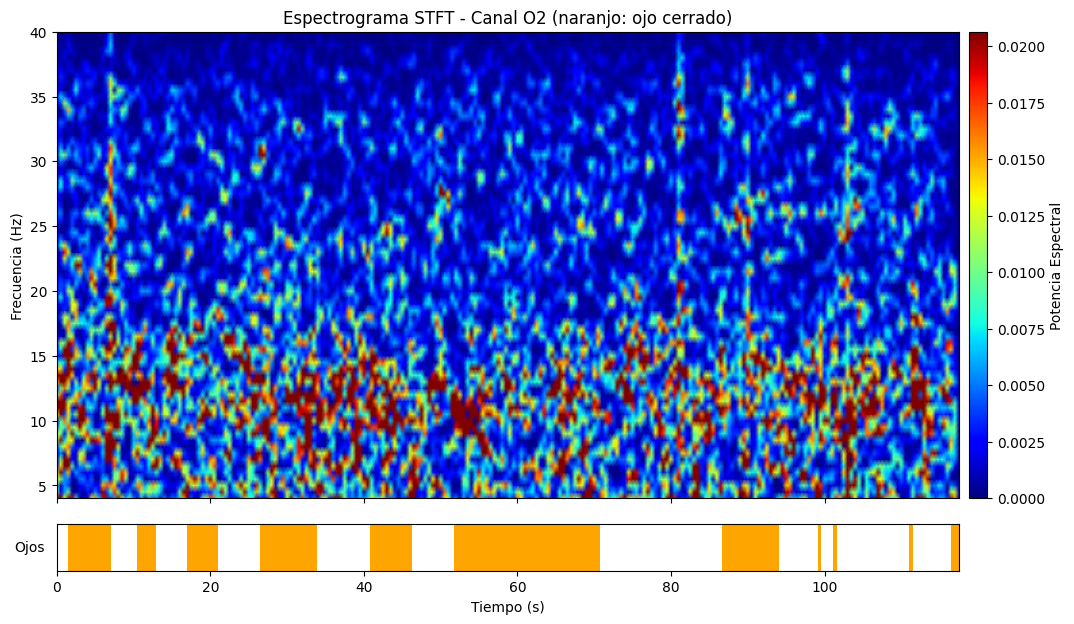

In [5]:
# --- Computar STFT para los 14 canales ---
stft_arrays = {}
stft_freqs, stft_times = None, None

for ch in CHANNELS:
    f, t, power = apply_stft(df[ch])
    
    # Recortar al mismo rango que la CWT aplicada posteriormente (4–40 Hz)
    # Así ambas representaciones analizan exactamente las mismas bandas
    # y la comparación downstream es metodológicamente válida
    freq_mask    = (f >= 4) & (f <= 40)
    stft_arrays[ch] = power[freq_mask, :]

    if stft_freqs is None:
        stft_freqs = f[freq_mask]
        stft_times = t

labels_stft = np.array([
    df.iloc[(df['time_sec'] - ti).abs().idxmin()][TARGET_COL]
    for ti in stft_times
])

# --- Visualización O2 ---
target = 'O2'
psd_viz = stft_arrays[target]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)
im = ax1.pcolormesh(stft_times, stft_freqs, psd_viz, shading='gouraud', cmap='jet',
                    vmin=0, vmax=np.percentile(psd_viz, 95))
ax1.set_title(f'Espectrograma STFT - Canal {target} (naranjo: ojo cerrado)')
ax1.set_ylabel('Frecuencia (Hz)')
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im, cax=cax, label='Potencia Espectral')
states_matrix = labels_stft.reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])
ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye,
           extent=[stft_times.min(), stft_times.max(), 0, 1], interpolation='nearest')
ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')
ax1.set_xlim(stft_times.min(), stft_times.max())
ax2.set_xlim(stft_times.min(), stft_times.max())
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="2%", pad=0.1)
cax2.axis('off')
plt.show()

## Transformada de Wavelet


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pywt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path

In [7]:
def apply_cwt(series, fs=FS, freq_min=4, freq_max=40, n_freqs=80, wavelet='cmor1.5-1.0'):
    """
    Aplica la Transformada Wavelet Continua (CWT) a una señal EEG.

    Parámetros
    ----------
    series    : array-like  - Señal de entrada (1D).
    fs        : int         - Frecuencia de muestreo en Hz.
    freq_min  : float       - Frecuencia mínima de análisis en Hz (default: 4 Hz, inicio de banda theta).
    freq_max  : float       - Frecuencia máxima de análisis en Hz (default: 40 Hz, consistente con filtro).
    n_freqs   : int         - Número de escalas (resolución frecuencial).
    wavelet   : str         - Wavelet madre. Se usa Morlet compleja (cmor) por
                              su localización conjunta tiempo-frecuencia.

    Retorna
    -------
    freqs     : ndarray     - Frecuencias correspondientes a cada escala (Hz).
    t         : ndarray     - Vector de tiempo (s).
    power     : ndarray     - Densidad de potencia espectral |CWT|² (freqs x tiempo).
    """
    # Calcular escalas a partir del rango de frecuencias deseado
    # pywt.scale2frequency convierte escala → frecuencia: f = f_c / (escala * dt)
    dt = 1.0 / fs
    central_freq = pywt.central_frequency(wavelet)
    
    # Espaciado LOGARÍTMICO de frecuencias (no lineal).
    # la CWT es un análisis multi-resolución por naturaleza — a bajas
    # frecuencias usa wavelets largos (alta res. frecuencial) y a altas frecuencias
    # usa wavelets cortos (alta res. temporal). El log-spacing respeta esa geometría, pues
    # distribuye los n_freqs bins uniformemente por octava (4-8 Hz, 8-16 Hz, 16-32 Hz),
    # en vez de concentrarlos artificialmente en las frecuencias bajas como hace linspace.
    # Esto es coherente con la literatura EEG y con la comparación frente a la STFT,
    # cuya resolución uniforme (lineal) es precisamente la limitación que la CWT supera.
    freqs_desired = np.logspace(np.log10(freq_min), np.log10(freq_max), n_freqs)
    
    scales = central_freq / (freqs_desired * dt)
    scales = scales[::-1]  # ordenar de menor a mayor escala (mayor a menor frecuencia)

    signal = np.array(series, dtype=np.float64)
    coeffs, freqs = pywt.cwt(signal, scales, wavelet, sampling_period=dt)

    # Densidad de potencia: módulo al cuadrado de los coeficientes complejos
    power = np.abs(coeffs) ** 2
    t = np.arange(len(signal)) * dt

    return freqs, t, power

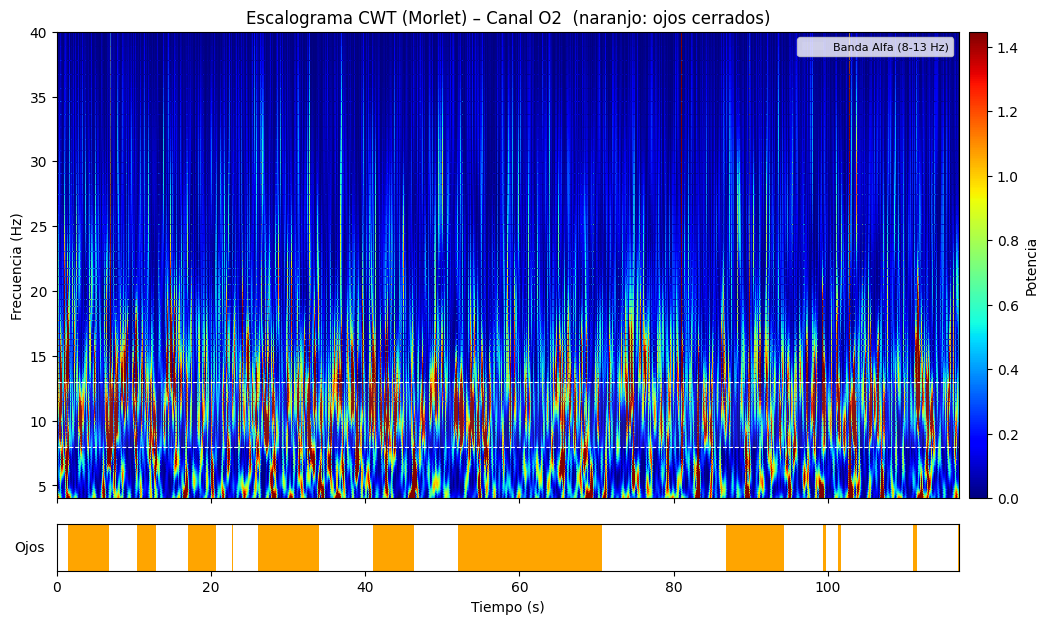

In [8]:
# --- Computar CWT para los 14 canales ---
cwt_arrays = {}
cwt_freqs_arr, cwt_times_arr = None, None

for ch in CHANNELS:
    freqs_cwt, t_cwt, power = apply_cwt(df[ch], fs=FS)
    cwt_arrays[ch] = power
    if cwt_freqs_arr is None:
        cwt_freqs_arr = freqs_cwt
        cwt_times_arr = t_cwt

# La CWT preserva la resolución temporal original (una columna por muestra),
# por lo que los labels están perfectamente alineados con los índices del df.
# No se necesita búsqueda — asignación directa O(1) en vez de O(N²).
labels_cwt = df[TARGET_COL].values

# --- Visualización O2 ---
target    = 'O2'
power_viz = cwt_arrays[target]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)
im = ax1.pcolormesh(cwt_times_arr, cwt_freqs_arr, power_viz, shading='gouraud', cmap='jet',
                    vmin=0, vmax=np.percentile(power_viz, 95))
ax1.axhspan(8, 13, color='white', alpha=0.08, lw=0, label='Banda Alfa (8-13 Hz)')
ax1.axhline(8,  color='white', linestyle='--', linewidth=0.8)
ax1.axhline(13, color='white', linestyle='--', linewidth=0.8)
ax1.set_title(f'Escalograma CWT (Morlet) – Canal {target}  (naranjo: ojos cerrados)')
ax1.set_ylabel('Frecuencia (Hz)')
ax1.legend(loc='upper right', fontsize=8)
divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im, cax=cax, label='Potencia')
states_matrix = labels_cwt.reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])
ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye,
           extent=[cwt_times_arr.min(), cwt_times_arr.max(), 0, 1], interpolation='nearest')
ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')
ax1.set_xlim(cwt_times_arr.min(), cwt_times_arr.max())
ax2.set_xlim(cwt_times_arr.min(), cwt_times_arr.max())
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='2%', pad=0.1)
cax2.axis('off')
plt.show()

### Cono de Influencia (CoI)

La CWT utiliza wavelets de extensión temporal variable: a bajas frecuencias el wavelet 
es más largo y requiere mayor contexto temporal para calcular correctamente el coeficiente. 
Cerca de los bordes de la señal (t=0 y t=T_total), el wavelet se extiende parcialmente 
fuera del registro — esa zona se rellena con ceros — produciendo coeficientes no confiables. 
Esta región contaminada se denomina **Cono de Influencia (CoI)**.

#### Fórmula para `cmor{B}-{C}`

La envolvente gaussiana del wavelet de Morlet complejo tiene desviación estándar 
temporal $\sigma_t = \sqrt{B/2}$. A partir de esto, el *e-folding time* (tiempo 
característico de decaimiento de la envolvente) para una escala $s$ es:

$$\tau(s) = \sqrt{2} \cdot \sigma_t \cdot s \cdot dt = \sqrt{B} \cdot s \cdot dt$$

Reexpresando en función de la frecuencia, usando la relación $s = f_c\, /\, (f \cdot dt)$:

$$\tau(f) = \frac{\sqrt{B} \cdot f_c}{f}$$

donde $f_c$ es la frecuencia central del wavelet madre.

Para **`cmor1.5-1.0`**: $B = 1.5$, $f_c \approx 1.0$ Hz, por lo tanto:

$$\tau(f) = \frac{\sqrt{1.5}}{f} \approx \frac{1.225}{f} \quad \text{[segundos]}$$

| Frecuencia | CoI desde cada borde |
|:---:|:---:|
| 4 Hz  | 0.31 s |
| 8 Hz  | 0.15 s |
| 13 Hz | 0.09 s |
| 40 Hz | 0.03 s |

> **Nota:** con 117 s de registro el CoI es pequeño (< 0.31 s en todas las frecuencias 
> analizadas). Sin embargo, se marca en la visualización por rigor metodológico. 
> En el notebook de extracción de características, las ventanas temporales deberán 
> excluir esta región fronteriza.

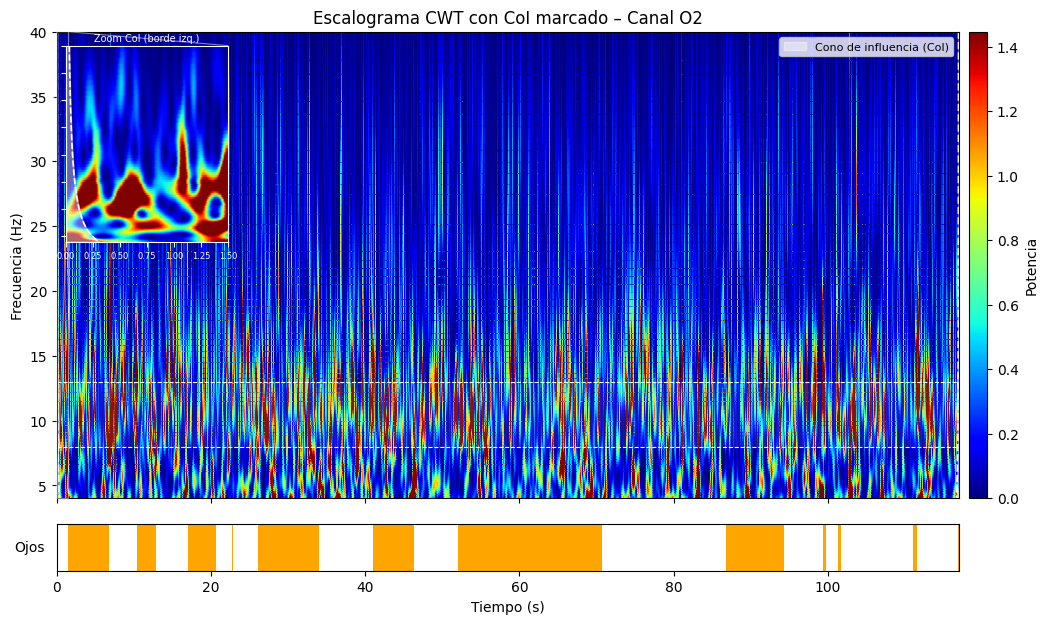

CoI máximo (f=4 Hz): 0.306 s → 0.26% del registro
CoI mínimo (f=40 Hz): 0.0306 s → 0.026% del registro


In [9]:
B       = 1.5  # bandwidth de cmor1.5-1.0
f_c     = pywt.central_frequency('cmor1.5-1.0')
T_total = cwt_times_arr[-1]

# Tiempo de CoI para cada frecuencia analizada
coi_times = np.sqrt(B) * f_c / cwt_freqs_arr  # shape: (n_freqs,)

target    = 'O2'
power_viz = cwt_arrays[target]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)

im = ax1.pcolormesh(cwt_times_arr, cwt_freqs_arr, power_viz, shading='gouraud',
                    cmap='jet', vmin=0, vmax=np.percentile(power_viz, 95))

# Banda alfa
ax1.axhspan(8, 13, color='white', alpha=0.08, lw=0)
ax1.axhline(8,  color='white', linestyle='--', linewidth=0.8)
ax1.axhline(13, color='white', linestyle='--', linewidth=0.8)

# CoI: zona sombreada + línea de frontera
ax1.fill_betweenx(cwt_freqs_arr, 0, coi_times,
                  color='white', alpha=0.4, label='Cono de influencia (CoI)')
ax1.fill_betweenx(cwt_freqs_arr, T_total - coi_times, T_total,
                  color='white', alpha=0.4)
ax1.plot(coi_times,           cwt_freqs_arr, 'w--', linewidth=1.4)
ax1.plot(T_total - coi_times, cwt_freqs_arr, 'w--', linewidth=1.4)

ax1.set_title(f'Escalograma CWT con CoI marcado – Canal {target}')
ax1.set_ylabel('Frecuencia (Hz)')
ax1.legend(loc='upper right', fontsize=8)
divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im, cax=cax, label='Potencia')

# ── Inset: zoom en borde izquierdo para visualizar el CoI ─────────────────
# El CoI máximo es ~0.31s, invisible en la escala de 117s.
# El inset muestra los primeros 1.5s donde la forma del cono es apreciable.
ZOOM_MAX_T = 1.5  # segundos a mostrar en el inset
t_mask = cwt_times_arr <= ZOOM_MAX_T

ax_inset = ax1.inset_axes([0.01, 0.55, 0.18, 0.42])  # [x, y, ancho, alto] en fracción de ax1
ax_inset.pcolormesh(cwt_times_arr[t_mask], cwt_freqs_arr,
                    power_viz[:, t_mask], shading='gouraud',
                    cmap='jet', vmin=0, vmax=np.percentile(power_viz, 95))

ax_inset.fill_betweenx(cwt_freqs_arr, 0, coi_times,
                       color='white', alpha=0.4)
ax_inset.plot(coi_times, cwt_freqs_arr, 'w--', linewidth=1.2)

ax_inset.set_xlim(0, ZOOM_MAX_T)
ax_inset.set_ylim(cwt_freqs_arr.min(), cwt_freqs_arr.max())
ax_inset.set_title('Zoom CoI (borde izq.)', fontsize=7, color='white', pad=3)
ax_inset.tick_params(labelsize=6, colors='white')
ax_inset.set_facecolor('black')
for spine in ax_inset.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(0.8)

# Rectángulo indicando la región del inset en el plot principal
ax1.indicate_inset_zoom(ax_inset, edgecolor='white', linewidth=0.8)

# ── Barra de estado ocular ─────────────────────────────────────────────────
states_matrix = labels_cwt.reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])
ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye,
           extent=[cwt_times_arr.min(), cwt_times_arr.max(), 0, 1],
           interpolation='nearest')
ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')
ax1.set_xlim(0, T_total)
ax2.set_xlim(0, T_total)
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='2%', pad=0.1)
cax2.axis('off')
plt.show()

print("CoI máximo (f={:.0f} Hz): {:.3f} s → {:.2f}% del registro".format(
    cwt_freqs_arr.min(), coi_times.max(), 100 * coi_times.max() / T_total))
print("CoI mínimo (f={:.0f} Hz): {:.4f} s → {:.3f}% del registro".format(
    cwt_freqs_arr.max(), coi_times.min(), 100 * coi_times.min() / T_total))

## GSP

Las técnicas STFT y CWT analizan cada canal EEG de forma **independiente**:
toman una señal 1D y la descomponen en tiempo y frecuencia. Sin embargo, el
cerebro es un sistema distribuido — la actividad eléctrica no ocurre de forma
aislada en cada electrodo, sino en **patrones coordinados entre regiones**.
La pregunta que surge naturalmente es: ¿cómo representar esa estructura espacial?

El **Graph Signal Processing (GSP)** responde esta pregunta tratando los
electrodos como nodos de una red (grafo) y generalizando el análisis espectral
a esa estructura.

---

#### 1. Grafo de conectividad

Primero se necesita definir *cómo están conectados* los electrodos. En lugar
de usar distancias físicas en el cuero cabelludo, se usa el algoritmo de
**Kalofolias**, que *aprende* los pesos de las conexiones directamente
desde los datos: dos electrodos tendrán una arista de mayor peso si sus señales
son estadísticamente similares a lo largo del registro.

El resultado es una **matriz de adyacencia** $W$ de dimensión $14 \times 14$,
donde $W_{i,j}$ indica cuán fuertemente conectados están los electrodos $i$ y
$j$ según la actividad EEG.

---

#### 2. Laplaciano del grafo y su descomposición

A partir de $W$ se construye el **Laplaciano** $L = D - W$, donde $D$ es la
matriz de grado (diagonal con la suma de pesos de cada nodo). El Laplaciano
codifica la estructura topológica del grafo y es el equivalente en grafos del
operador diferencial de la Fourier clásica.

Su descomposición espectral es:

$$L = U \Lambda U^\top$$

donde:

- $U \in \mathbb{R}^{14 \times 14}$: matriz de **autovectores**, cuyos columnas
  son los **modos espaciales** del grafo. Cada columna de $U$ es un patrón de
  activación distribuida sobre los 14 electrodos.
- $\Lambda$: matriz diagonal de **autovalores**
  $\lambda_0 \leq \lambda_1 \leq \cdots \leq \lambda_{13}$, que indican la
  **suavidad espacial** de cada modo:
  - $\lambda_0 \approx 0$ → modo más suave: todos los electrodos activos de
    forma similar (componente de modo común, análogo al DC en Fourier).
  - $\lambda_{13}$ grande → modo más oscilatorio: electrodos vecinos con
    actividad muy distinta (análogo a la alta frecuencia en Fourier).

---

#### 3. GFT y el espectrograma de grafo

La **Transformada de Fourier del Grafo** proyecta la señal EEG sobre la base
de modos espaciales:

$$\hat{x}(t) = U^\top \, x(t)$$

donde $x(t) \in \mathbb{R}^{14}$ es el vector de los 14 canales en el instante
$t$. El resultado $\hat{x}(t) \in \mathbb{R}^{14}$ indica **cuánto de cada modo
espacial está presente en ese instante**.

Al calcular $\left|\hat{x}(t)\right|^2$ para todos los instantes de tiempo se
obtiene el **espectrograma de grafo**: una matriz de $14\ \text{modos} \times N\
\text{instantes}$ que muestra cómo evoluciona la energía de cada patrón espacial
a lo largo del tiempo.

---

#### ¿Qué se puede leer en el espectrograma de grafo?

| Eje / elemento | Significado |
|---|---|
| Eje X | Tiempo (igual que en STFT/CWT) |
| Eje Y | Modos espaciales $\lambda_0 \ldots \lambda_{13}$ **(NO son Hz)** |
| Color | Energía del modo $k$ en el instante $t$ (dB) |

Si durante los períodos de **ojos cerrados** se observa mayor energía en un
modo particular, eso significa que ese *patrón espacial de activación* es
característico de ese estado. Fisiológicamente, el ritmo alfa en reposo con
ojos cerrados involucra actividad occipital sincronizada — lo que
correspondería a un modo de baja frecuencia de grafo ($\lambda$ pequeño) con
carga alta en los electrodos O1 y O2.

---

#### Diferencia fundamental con STFT y CWT

|  | STFT / CWT | GFT |
|---|---|---|
| Dominio de análisis | Frecuencia temporal (Hz) | Frecuencia espacial ($\lambda$) |
| Unidad del eje Y | Hz | Autovalores del Laplaciano |
| Canal analizado | Uno a la vez | Los 14 simultáneamente |
| Captura sincronía inter-canal | No directamente | Sí |

Por esta razón, el GSP **no es una técnica TF en el sentido clásico** y no
puede compararse directamente con STFT y CWT en las mismas métricas. Se
presenta como una representación **complementaria** que captura la dimensión
espacial de la actividad EEG, inaccesible mediante los métodos anteriores.

In [10]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.ndimage
from eegrasp import EEGrasp

Found solution after 238 iterations
Found solution after 238 iterations
GSP — Espectrograma: (14, 14980)  (modos x tiempo)
Autovalores: [0.    0.028 0.107 0.199 0.327 0.446 0.482 0.7   0.858 0.904 1.022 1.098
 1.156 1.359]


/tmp/ipykernel_3224/4259402339.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


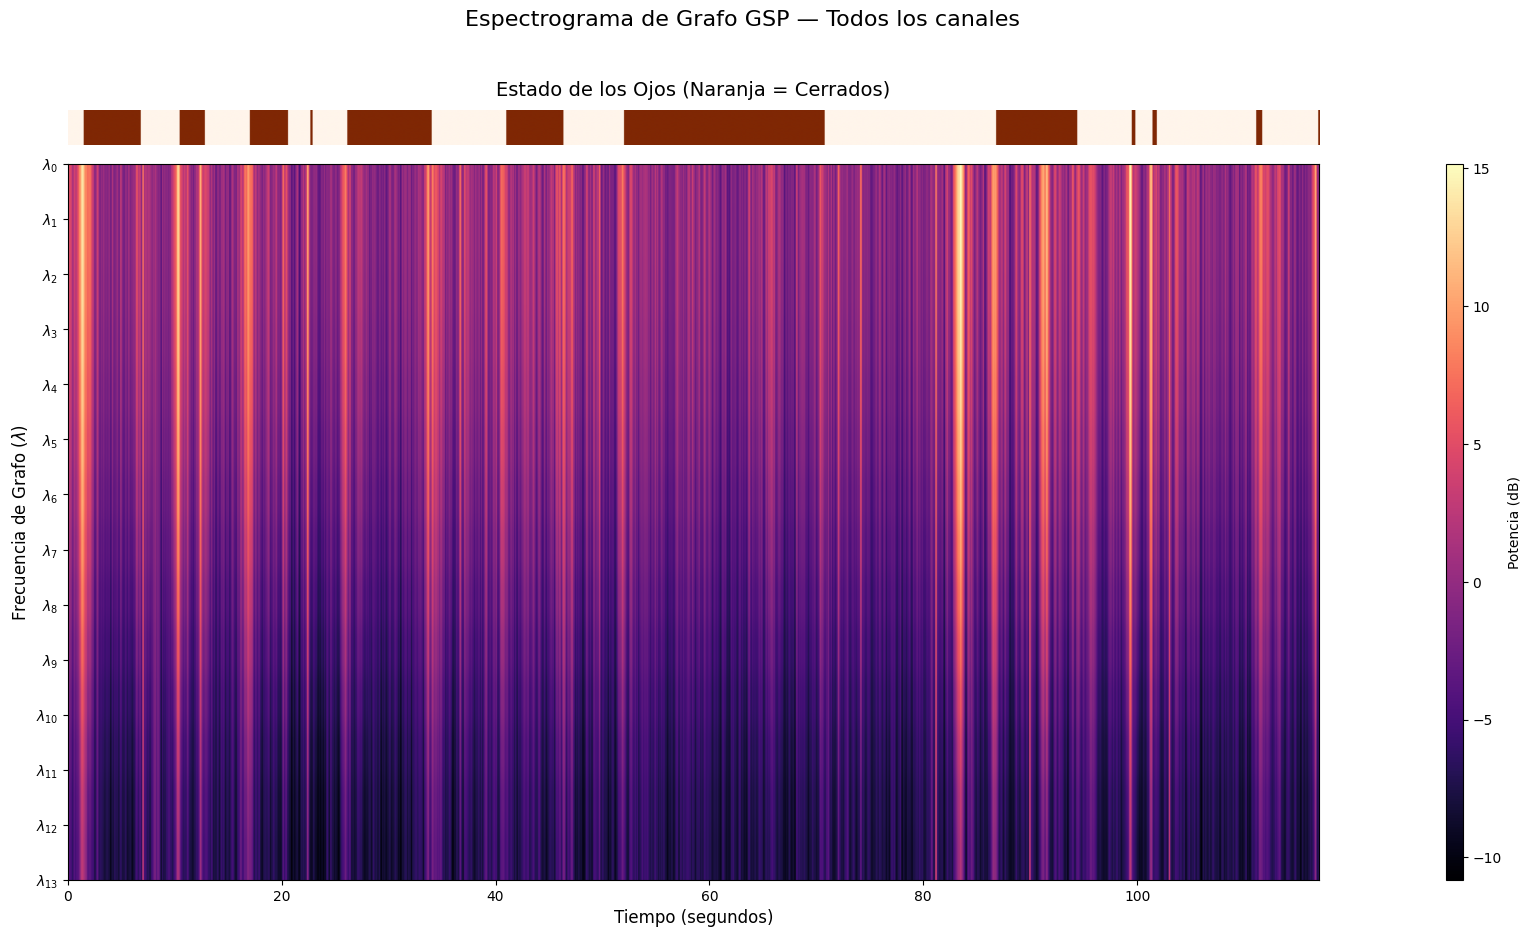

In [11]:
# ── 1. Posiciones 3D de los electrodos (montaje estándar 10-20) ────────────
# Se necesitan las coordenadas 3D para que EEGrasp pueda usar la geometría
# del cuero cabelludo como información auxiliar al aprender el grafo.
base_montage = mne.channels.make_standard_montage('standard_1020')
eeg_pos_dict = base_montage.get_positions()['ch_pos']
eeg_pos      = np.array([eeg_pos_dict[ch] for ch in CHANNELS])  # (14, 3)

# ── 2. Construir Grafo Aprendido (Kalofolias) ──────────────────────────────
# learn_graph infiere los pesos W[i,j] desde la similitud estadística entre
# canales. Los parámetros a y b controlan suavidad y dispersidad del grafo.
eeg_data = df[CHANNELS].values.T   # (14, N): canales × muestras
gsp      = EEGrasp(coordinates=eeg_pos, labels=CHANNELS)
gsp.data = eeg_data
W, _     = gsp.learn_graph(a=0.34, b=0.4)
G        = gsp.compute_graph(W)

# ── 3. Base de Fourier del Grafo ───────────────────────────────────────────
# El Laplaciano L = D - W codifica la topología del grafo.
# Su descomposición L = U Λ Uᵀ produce:
#   U     → modos espaciales (patrones de activación entre electrodos)
#   evals → autovalores λ (suavidad espacial de cada modo)
G.set_coordinates(eeg_pos)
G.compute_laplacian()
G.compute_fourier_basis()
evals = np.array(G.e)   # autovalores  shape: (14,)
U     = np.array(G.U)   # autovectores shape: (14, 14)

# ── 4. GFT ventana a ventana → Espectrograma de Grafo ─────────────────────
# x_hat[k, t] = energía del modo k en el instante t
# Se descompone el vector de 14 canales en los 14 modos espaciales. 
# NO hay ventaneo temporal, la proyección es una operación matricial instantánea aplicada sample a sample.
x_hat = U.T @ eeg_data                    # shape: (14, N)
graph_spectrogram = x_hat ** 2            # potencia por modo y tiempo

# Suavizado gaussiano para mejor visualización
graph_spectrogram_smooth = scipy.ndimage.gaussian_filter(graph_spectrogram, sigma=5)
graph_spectrogram_log    = 10 * np.log10(graph_spectrogram_smooth + 1e-6)

# Eje temporal y extent para imshow
n_muestras   = eeg_data.shape[1]
tiempo_total = n_muestras / FS
times_gsp    = np.linspace(0, tiempo_total, n_muestras)
extent       = [0, tiempo_total, len(evals) - 1, 0]

# Labels alineadas al eje temporal completo
labels_gsp = df[TARGET_COL].values        # shape: (N,)

print(f"GSP — Espectrograma: {graph_spectrogram_log.shape}  (modos x tiempo)")
print(f"Autovalores: {evals.round(3)}")

# ── 5. Visualización ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, height_ratios=[0.05, 1],
                         width_ratios=[1.5, 0.02], hspace=0.05)

ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(labels_gsp[np.newaxis, :], aspect='auto', cmap='Oranges',
           extent=[0, tiempo_total, 0, 1])
ax0.set_axis_off()
ax0.set_title('Estado de los Ojos (Naranja = Cerrados)', fontsize=14, pad=10)

ax1 = fig.add_subplot(gs[1, 0])
im  = ax1.imshow(graph_spectrogram_log, aspect='auto', cmap='magma', extent=extent)
ax1.set_xlabel('Tiempo (segundos)', fontsize=12)
ax1.set_ylabel('Frecuencia de Grafo ($\\lambda$)', fontsize=12)
ax1.set_yticks(range(len(evals)))
ax1.set_yticklabels([f'$\\lambda_{{{i}}}$' for i in range(len(evals))])

cbar_ax = fig.add_subplot(gs[1, 1])
fig.colorbar(im, cax=cbar_ax, label='Potencia (dB)')
plt.suptitle('Espectrograma de Grafo GSP — Todos los canales', fontsize=16)
plt.tight_layout()
plt.show()

## Guardado y Verificacion

In [12]:
from pathlib import Path

save_dir = Path('./data/tf_representations')
save_dir.mkdir(parents=True, exist_ok=True)

# ── Guardar ────────────────────────────────────────────────────────────────
np.savez(save_dir / 'stft.npz',
         **stft_arrays,
         freqs=stft_freqs, times=stft_times, labels=labels_stft)

np.savez(save_dir / 'cwt.npz',
         **cwt_arrays,
         freqs=cwt_freqs_arr, times=cwt_times_arr, labels=labels_cwt)

np.savez(save_dir / 'gsp.npz',
         spectrogram=graph_spectrogram_log,   # (14, N) — modos × tiempo
         eigenvalues=evals,                    # (14,)
         times=times_gsp,                      # (N,)
         labels=labels_gsp,                    # (N,)
         U=U,                                  # (14, 14) — eigenvectores
         channels=np.array(CHANNELS))

# ── Verificar ──────────────────────────────────────────────────────────────
print(f"Archivos guardados en: {save_dir.resolve()}\n")

for name in ['stft.npz', 'cwt.npz']:
    data = np.load(save_dir / name)
    print(f"{name}:")
    print(f"  Claves     : {list(data.keys())}")
    print(f"  Shape O2   : {data['O2'].shape}")
    print(f"  Shape freqs: {data['freqs'].shape}  |  times: {data['times'].shape}  |  labels: {data['labels'].shape}")
    print(f"  Clases     : {np.unique(data['labels'])}")
    print(f"  Canales OK : {all(ch in data for ch in CHANNELS)}")
    print()

gsp_data = np.load(save_dir / 'gsp.npz', allow_pickle=True)
print("gsp.npz:")
print(f"  Claves          : {list(gsp_data.keys())}")
print(f"  Shape espectrograma: {gsp_data['spectrogram'].shape}  (modos × tiempo)")
print(f"  Shape eigenvalues  : {gsp_data['eigenvalues'].shape}")
print(f"  Shape times        : {gsp_data['times'].shape}")
print(f"  Shape labels       : {gsp_data['labels'].shape}")
print(f"  Shape U            : {gsp_data['U'].shape}")
print(f"  Clases             : {np.unique(gsp_data['labels'])}")

Archivos guardados en: /home/jsuarez/workspaces/USM/signal-images/Proyecto_INF405/data/tf_representations

stft.npz:
  Claves     : ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'freqs', 'times', 'labels']
  Shape O2   : (73, 236)
  Shape freqs: (73,)  |  times: (236,)  |  labels: (236,)
  Clases     : [0. 1.]
  Canales OK : True

cwt.npz:
  Claves     : ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'freqs', 'times', 'labels']
  Shape O2   : (80, 14980)
  Shape freqs: (80,)  |  times: (14980,)  |  labels: (14980,)
  Clases     : [0 1]
  Canales OK : True

gsp.npz:
  Claves          : ['spectrogram', 'eigenvalues', 'times', 'labels', 'U', 'channels']
  Shape espectrograma: (14, 14980)  (modos × tiempo)
  Shape eigenvalues  : (14,)
  Shape times        : (14980,)
  Shape labels       : (14980,)
  Shape U            : (14, 14)
  Clases             : [0 1]
